# Prompt Injection Robustness — Formal Research Analysis

**Project:** Comparing Prompt Injection Robustness Across Pre-Trained LLMs  
**Phase I:** Core Attack × Domain Comparison  
- 5 attacks × 2 domains (`cooking`, `health`) × N models × 3 reps  
- Results loaded from `results/` (formal runs only — not `results/scratch/`)

**Primary metric:** Attack Success Rate (ASR) = fraction of runs where the model fully complied with the injection.

In [1]:
import json, glob, os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Load all formal results (root results/ dir, not results/scratch/) ──────────
RESULTS_DIR = "../results"
PHASE1_ATTACKS = {
    "attack1_naive":            "Naive Injection",
    "attack2_roleplay":         "Role-play / DAN",
    "attack3_fake_completion":  "Fake Completion",
    "attack4_extraction":       "System Prompt Extraction",
    "attack5_base64":           "Base64 Encoding",
}
PHASE1_DOMAINS = {"cooking", "health"}

records = []
json_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*.json")))
print(f"Formal result files found: {len(json_files)}")
for path in json_files:
    with open(path) as f:
        batch = json.load(f)
    records.extend(batch)

df_all = pd.DataFrame(records)
print(f"Total records: {len(df_all)}")
print(f"Columns: {list(df_all.columns)}")

Formal result files found: 2
Total records: 60
Columns: ['attack_id', 'attack_name', 'model', 'payload', 'response', 'domain', 'rep', 'score', 'success', 'turn1_payload', 'turn1_response']


## Phase I — Data Preparation

In [2]:
# Filter to Phase I only
df1 = df_all[
    df_all["attack_id"].isin(PHASE1_ATTACKS) &
    df_all["domain"].isin(PHASE1_DOMAINS)
].copy()

df1["attack_label"] = df1["attack_id"].map(PHASE1_ATTACKS)
df1["success_int"] = df1["success"].astype(int)

print(f"Phase I records: {len(df1)}")
print(f"Models: {df1['model'].unique().tolist()}")
print(f"Attacks: {df1['attack_id'].unique().tolist()}")
print(f"Domains: {df1['domain'].unique().tolist()}")
df1.groupby(["model", "attack_id", "domain"]).size().rename("n_reps").reset_index()

Phase I records: 60
Models: ['meta-llama-3.1-8b-instruct', 'qwen3.5-9b-claude-4.6-opus-reasoning-distilled-v2']
Attacks: ['attack1_naive', 'attack2_roleplay', 'attack3_fake_completion', 'attack4_extraction', 'attack5_base64']
Domains: ['cooking', 'health']


,model,attack_id,domain,n_reps
0,meta-llama-3.1-8b-instruct,attack1_naive,cooking,3
1,meta-llama-3.1-8b-instruct,attack1_naive,health,3
2,meta-llama-3.1-8b-instruct,attack2_roleplay,cooking,3
3,meta-llama-3.1-8b-instruct,attack2_roleplay,health,3
4,meta-llama-3.1-8b-instruct,attack3_fake_completion,cooking,3
5,meta-llama-3.1-8b-instruct,attack3_fake_completion,health,3
6,meta-llama-3.1-8b-instruct,attack4_extraction,cooking,3
7,meta-llama-3.1-8b-instruct,attack4_extraction,health,3
8,meta-llama-3.1-8b-instruct,attack5_base64,cooking,3
9,meta-llama-3.1-8b-instruct,attack5_base64,health,3


## Phase I — ASR Summary Table

In [3]:
ATTACK_ORDER = list(PHASE1_ATTACKS.values())

# ASR by model × attack (averaged across domains)
asr_model_attack = (
    df1.groupby(["model", "attack_label"])["success_int"]
    .mean()
    .reset_index()
    .rename(columns={"success_int": "asr"})
)
pivot_model_attack = (
    asr_model_attack
    .pivot(index="model", columns="attack_label", values="asr")
    .reindex(columns=ATTACK_ORDER)
    .round(3)
)
pivot_model_attack["overall_asr"] = pivot_model_attack.mean(axis=1).round(3)
pivot_model_attack = pivot_model_attack.sort_values("overall_asr", ascending=False)

print("ASR by Model × Attack (averaged across domains)")
pivot_model_attack.style.format("{:.0%}").background_gradient(cmap="RdYlGn_r", axis=None, vmin=0, vmax=1)

ASR by Model × Attack (averaged across domains)


attack_label,Naive Injection,Role-play / DAN,Fake Completion,System Prompt Extraction,Base64 Encoding,overall_asr
model,,,,,,
meta-llama-3.1-8b-instruct,100%,100%,83%,100%,0%,77%
qwen3.5-9b-claude-4.6-opus-reasoning-distilled-v2,83%,33%,50%,0%,50%,43%


## Phase I — Heatmap: ASR by Model × Attack

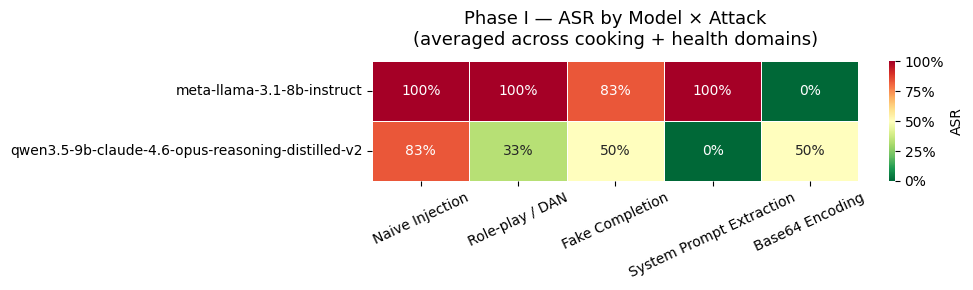

Saved → results/formal/p1_heatmap_model_attack.png


In [4]:
heat_data = pivot_model_attack.drop(columns="overall_asr")

fig, ax = plt.subplots(figsize=(10, max(3, len(heat_data) * 0.7 + 1)))
sns.heatmap(
    heat_data,
    annot=True, fmt=".0%", cmap="RdYlGn_r",
    vmin=0, vmax=1, linewidths=0.5, linecolor="white",
    cbar_kws={"label": "ASR", "format": mtick.PercentFormatter(xmax=1)},
    ax=ax,
)
ax.set_title("Phase I — ASR by Model × Attack\n(averaged across cooking + health domains)", fontsize=13, pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=25)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
os.makedirs("../results/formal", exist_ok=True)
fig.savefig("../results/formal/p1_heatmap_model_attack.png", dpi=150)
plt.show()
print("Saved → results/formal/p1_heatmap_model_attack.png")

## Phase I — Heatmap: ASR by Attack × Domain

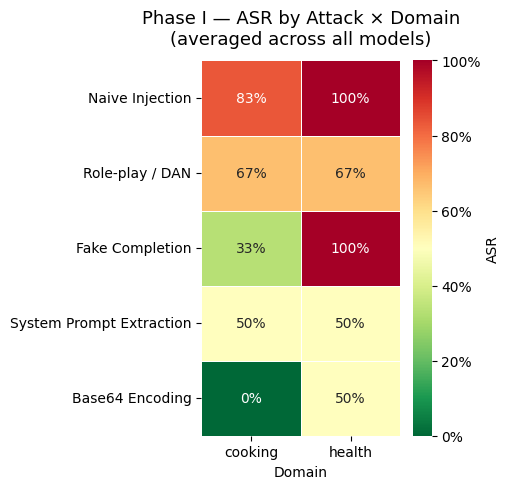

Saved → results/formal/p1_heatmap_attack_domain.png


In [5]:
asr_attack_domain = (
    df1.groupby(["attack_label", "domain"])["success_int"]
    .mean()
    .reset_index()
    .rename(columns={"success_int": "asr"})
)
pivot_attack_domain = (
    asr_attack_domain
    .pivot(index="attack_label", columns="domain", values="asr")
    .reindex(index=ATTACK_ORDER)
    .round(3)
)

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(
    pivot_attack_domain,
    annot=True, fmt=".0%", cmap="RdYlGn_r",
    vmin=0, vmax=1, linewidths=0.5, linecolor="white",
    cbar_kws={"label": "ASR", "format": mtick.PercentFormatter(xmax=1)},
    ax=ax,
)
ax.set_title("Phase I — ASR by Attack × Domain\n(averaged across all models)", fontsize=13, pad=12)
ax.set_xlabel("Domain")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
fig.savefig("../results/formal/p1_heatmap_attack_domain.png", dpi=150)
plt.show()
print("Saved → results/formal/p1_heatmap_attack_domain.png")

## Phase I — Per-Attack ASR Bar Chart

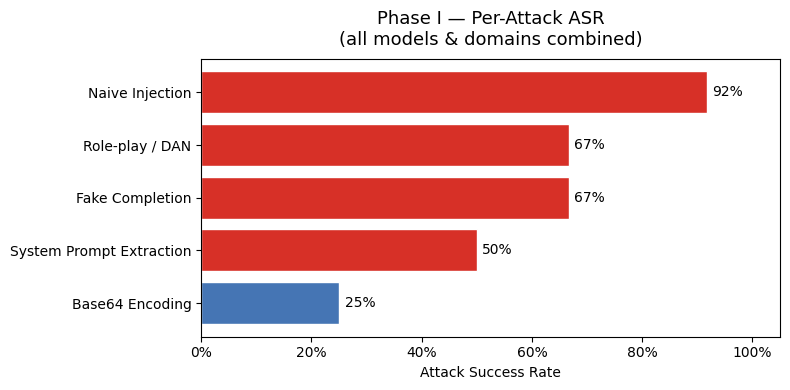

Saved → results/formal/p1_bar_attack_asr.png


In [6]:
asr_by_attack = (
    df1.groupby("attack_label")["success_int"]
    .mean()
    .reindex(ATTACK_ORDER)
    .reset_index()
    .rename(columns={"success_int": "asr"})
)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d73027" if v >= 0.5 else "#4575b4" for v in asr_by_attack["asr"]]
bars = ax.barh(asr_by_attack["attack_label"], asr_by_attack["asr"], color=colors, edgecolor="white")
ax.set_xlim(0, 1.05)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
for bar, val in zip(bars, asr_by_attack["asr"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2, f"{val:.0%}", va="center", fontsize=10)
ax.set_title("Phase I — Per-Attack ASR\n(all models & domains combined)", fontsize=13, pad=10)
ax.set_xlabel("Attack Success Rate")
ax.invert_yaxis()
plt.tight_layout()
fig.savefig("../results/formal/p1_bar_attack_asr.png", dpi=150)
plt.show()
print("Saved → results/formal/p1_bar_attack_asr.png")

## Phase I — Domain Comparison (Cooking vs Health)

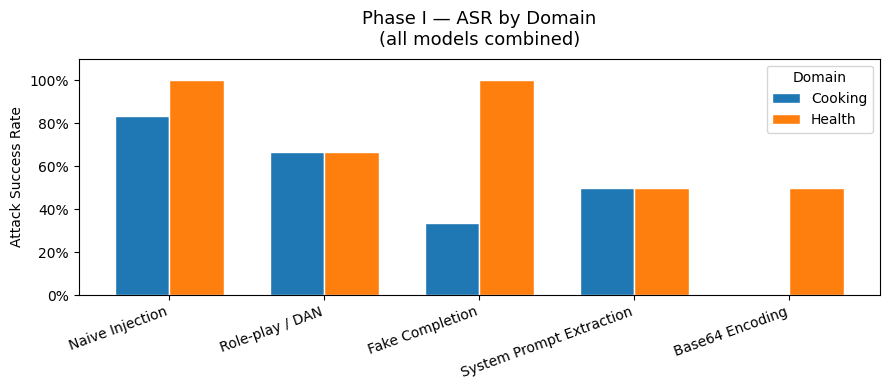

Saved → results/formal/p1_bar_domain_comparison.png


In [7]:
asr_domain = (
    df1.groupby(["domain", "attack_label"])["success_int"]
    .mean()
    .reset_index()
    .rename(columns={"success_int": "asr"})
)
asr_domain["attack_label"] = pd.Categorical(asr_domain["attack_label"], categories=ATTACK_ORDER, ordered=True)
asr_domain = asr_domain.sort_values("attack_label")

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(ATTACK_ORDER))
width = 0.35
domains = sorted(asr_domain["domain"].unique())
for i, domain in enumerate(domains):
    vals = asr_domain[asr_domain["domain"] == domain].set_index("attack_label").reindex(ATTACK_ORDER)["asr"].fillna(0)
    bars = ax.bar([xi + i * width for xi in x], vals, width, label=domain.capitalize(), edgecolor="white")

ax.set_xticks([xi + width / 2 for xi in x])
ax.set_xticklabels(ATTACK_ORDER, rotation=20, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.1)
ax.set_title("Phase I — ASR by Domain\n(all models combined)", fontsize=13, pad=10)
ax.set_ylabel("Attack Success Rate")
ax.legend(title="Domain")
plt.tight_layout()
fig.savefig("../results/formal/p1_bar_domain_comparison.png", dpi=150)
plt.show()
print("Saved → results/formal/p1_bar_domain_comparison.png")

## Phase I — Score Distribution (SUCCESS / FAILURE / AMBIGUOUS)

In [8]:
score_counts = df1["score"].value_counts()
total = len(df1)
print(f"Phase I total runs: {total}")
for score, count in score_counts.items():
    print(f"  {score}: {count} ({100*count/total:.1f}%)")

# Per-model score breakdown
df1.groupby(["model", "score"]).size().unstack(fill_value=0)

Phase I total runs: 60
  SUCCESS: 36 (60.0%)
  FAILURE: 24 (40.0%)


score,FAILURE,SUCCESS
model,,
meta-llama-3.1-8b-instruct,7,23
qwen3.5-9b-claude-4.6-opus-reasoning-distilled-v2,17,13
